# Text Mining Project — Market Sentiment Classification
**Spring Semester 2025/2026 | NOVA IMS**

Classifying financial tweets into three sentiment categories:
- **0 — Bearish** (negative / pessimistic)
- **1 — Bullish** (positive / optimistic)
- **2 — Neutral**

### Notebook structure
1. Data Exploration
2. Data Preprocessing
3. Corpus Split (Stratified K-Fold)
4. Feature Engineering *(BoW / TF-IDF, Word2Vec, Transformer Encoders)*
5. Classification Models *(Traditional ML + Transformer Fine-tuning)*
6. Evaluation & Analysis
7. Final Predictions on `test.csv`

<a class='anchor' id='toc'></a>
### **Table of Contents**
- [1. Data Exploration](#1)
  - [1.1 Duplicate Tweets](#1.1)
  - [1.2 Class Distribution](#1.2)
  - [1.3 Tweet Length Analysis](#1.3)
  - [1.4 Global Vocabulary](#1.4)
  - [1.5 Class-Specific Vocabulary](#1.5)
  - [1.6 Special Tweet Features (Hashtags, Mentions, URLs, Numbers)](#1.6)
  - [1.7 Top Hashtags & Cashtags](#1.7)
  - [1.8 Word Co-occurrence Heatmap](#1.8)
  - [1.9 Exploration Summary & Conclusions](#1.9)
- [2. Data Preprocessing](#2)
  - [2.1 Step-by-step Demonstration](#2.1)
  - [2.2 Lemmatization vs Stemming Comparison](#2.2)
  - [2.3 Classical Preprocessing Function](#2.3)
  - [2.4 Apply Preprocessing to the Full Training Set](#2.4)
  - [2.5 Before / After Comparison](#2.5)
  - [2.6 Vocabulary Impact](#2.6)
  - [2.7 Empty Tweets After Cleaning](#2.7)
  - [2.8 Save Preprocessed Dataset](#2.8)
- [3. Corpus Split — Stratified K-Fold](#3)
- [4. Feature Engineering](#4)
  - [4.1 Bag-of-Words & TF-IDF](#4.1)
  - [4.2 Word2Vec Embeddings](#4.2)
  - [4.3 Transformer Encoder Embeddings (FinBERT / BERT / RoBERTa)](#4.3)
- [5. Classification Models](#5)
  - [5.1 Evaluation Helper](#5.1)
  - [5.2 Traditional ML with TF-IDF (Classical Pipeline)](#5.2)
  - [5.3 Traditional ML with Word2Vec (Classical Pipeline)](#5.3)
  - [5.4 Transformer Encoder + Classifier](#5.4)
  - [5.5 Fine-tuned FinBERT (End-to-end Transformer)](#5.5)
- [6. Evaluation & Analysis](#6)
  - [6.1 Metric Interpretation in Context](#6.1)
- [7. Final Predictions on test.csv](#7)

---
## 1. Data Exploration

In [1]:
# Imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from itertools import combinations
import re
import string
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import SnowballStemmer
from nltk.stem.wordnet import WordNetLemmatizer

STOP         = set(stopwords.words('english'))
lemma        = WordNetLemmatizer()
stemmer      = SnowballStemmer('english')

# Consistent palette for the 3 classes
CLASS_COLORS = {0: '#e74c3c', 1: '#2ecc71', 2: '#3498db'}
CLASS_NAMES  = {0: 'Bearish (0)', 1: 'Bullish (1)', 2: 'Neutral (2)'}


In [ ]:
# Load training data 
df = pd.read_csv('train.csv')

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'Types:\n{df.dtypes}')
print(f'\nMissing values:\n{df.isnull().sum()}')
df.head(10)

Shape: (9543, 2)
Columns: ['text', 'label']
Types:
text     object
label     int64
dtype: object

Missing values:
text     0
label    0
dtype: int64


,text,label
0,$BYND - JPMorgan reels in expectations on Beyo...,0
1,$CCL $RCL - Nomura points to bookings weakness...,0
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...",0
3,$ESS: BTIG Research cuts to Neutral https://t....,0
4,$FNKO - Funko slides after Piper Jaffray PT cu...,0
5,$FTI - TechnipFMC downgraded at Berenberg but ...,0
6,$GM - GM loses a bull https://t.co/tdUfG5HbXy,0
7,$GM: Deutsche Bank cuts to Hold https://t.co/7...,0
8,$GTT: Cowen cuts to Market Perform,0
9,$HNHAF $HNHPD $AAPL - Trendforce cuts iPhone e...,0


### 1.1 Duplicate Tweets

In [ ]:
# Duplicates 
dup_text  = df.duplicated(subset='text').sum()
dup_both  = df.duplicated(subset=['text', 'label']).sum()

print(f'Duplicate tweets (same text):           {dup_text}')
print(f'Duplicate tweets (same text + label):   {dup_both}')

if dup_text > 0:
    mask = df.duplicated(subset='text', keep=False)
    conflicts = df[mask].groupby('text')['label'].nunique()
    conflicts = conflicts[conflicts > 1]
    print(f'\nTweets with conflicting labels (same text, different label): {len(conflicts)}')

Duplicate tweets (same text):           0
Duplicate tweets (same text + label):   0


### 1.2 Class Distribution

=== Tweet count per class ===
  Bearish (0): 1,442 tweets  (15.1%)
  Bullish (1): 1,923 tweets  (20.1%)
  Neutral (2): 6,178 tweets  (64.7%)


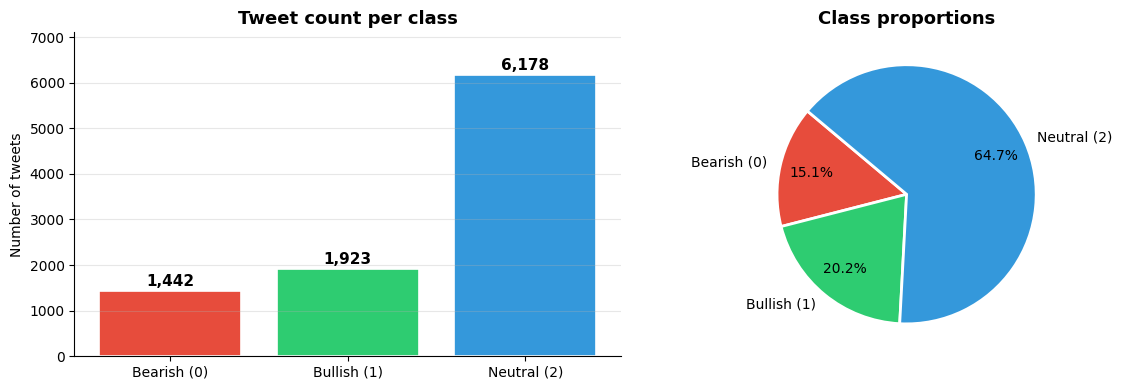


⚠️  Majority-class baseline: 64.7% — any model must beat this.


In [ ]:
# Class distribution 
label_counts = df['label'].value_counts().sort_index()
label_pct    = (label_counts / len(df) * 100).round(2)

print('=== Tweet count per class ===')
for lbl, cnt in label_counts.items():
    print(f'  {CLASS_NAMES[lbl]}: {cnt:,} tweets  ({label_pct[lbl]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = [CLASS_COLORS[i] for i in label_counts.index]
bars = axes[0].bar([CLASS_NAMES[i] for i in label_counts.index],
                   label_counts.values, color=colors, edgecolor='white', linewidth=1.2)
for bar, cnt in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{cnt:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Tweet count per class', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of tweets')
axes[0].set_ylim(0, label_counts.max() * 1.15)
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)

axes[1].pie(label_counts.values,
            labels=[CLASS_NAMES[i] for i in label_counts.index],
            autopct='%1.1f%%', colors=colors, startangle=140, pctdistance=0.75,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class proportions', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

majority_acc = label_counts.max() / len(df) * 100
print(f'\n⚠️  Majority-class baseline: {majority_acc:.1f}% — any model must beat this.')

### 1.3 Tweet Length Analysis

=== Length statistics (chars / words) ===
       n_chars  n_words
count   9543.0   9543.0
mean      85.9     12.2
std       35.1      4.7
min        2.0      1.0
25%       58.0      9.0
50%       79.0     11.0
75%      120.0     15.0
max      190.0     32.0


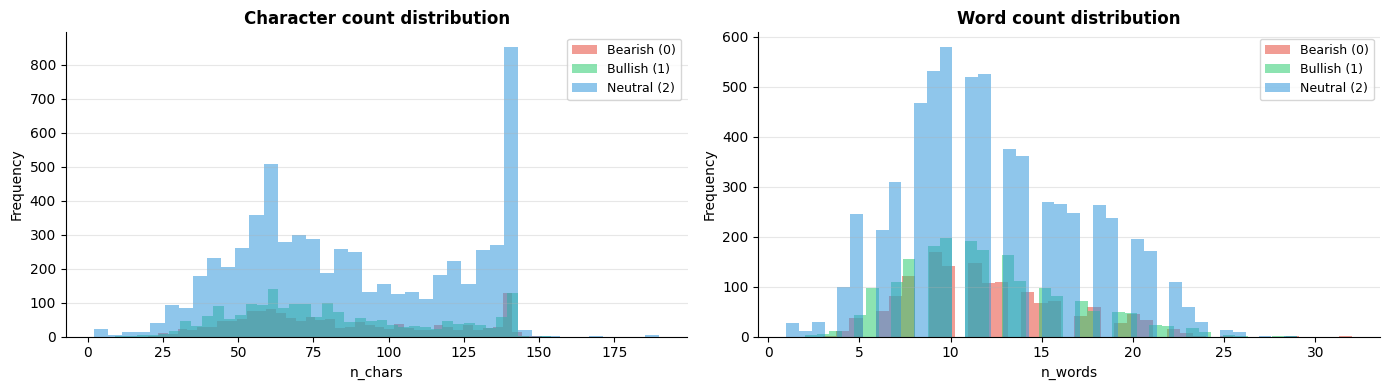


=== Average length per class ===
             n_chars  n_words
label                        
Bearish (0)     83.4     12.0
Bullish (1)     80.4     11.9
Neutral (2)     88.1     12.3


In [ ]:
# Tweet length 
df['n_chars'] = df['text'].str.len()
df['n_words'] = df['text'].str.split().str.len()

print('=== Length statistics (chars / words) ===')
print(df[['n_chars', 'n_words']].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for metric, ax, title in [
    ('n_chars', axes[0], 'Character count distribution'),
    ('n_words', axes[1], 'Word count distribution')
]:
    for lbl in [0, 1, 2]:
        subset = df[df['label'] == lbl][metric]
        ax.hist(subset, bins=40, alpha=0.55,
                color=CLASS_COLORS[lbl], label=CLASS_NAMES[lbl], edgecolor='none')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(metric)
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

print('\n=== Average length per class ===')
print(df.groupby('label')[['n_chars', 'n_words']].mean().round(1).rename(index=CLASS_NAMES))

### 1.4 Global Vocabulary

In [ ]:
# Helper tokeniser for exploration only (no model fit) 
def tokenize_explore(text):
    text  = str(text).lower()
    text  = re.sub(r'http\S+|www\S+', '', text)
    text  = re.sub(r'@\w+|#\w+', '', text)
    text  = re.sub(r'[^a-z\s]', ' ', text)
    tokens = word_tokenize(text)
    return [t for t in tokens if t not in STOP and len(t) > 2]

all_tokens = []
for txt in df['text']:
    all_tokens.extend(tokenize_explore(txt))

vocab  = set(all_tokens)
freq   = Counter(all_tokens)
top50  = freq.most_common(50)

print(f'Total tokens (no stopwords): {len(all_tokens):,}')
print(f'Unique vocabulary:           {len(vocab):,}')
print(f'\nTop 20 most frequent words:')
for word, cnt in top50[:20]:
    print(f'   {word:<20} {cnt:>5}')

Total tokens (no stopwords): 73,385
Unique vocabulary:           14,016

Top 20 most frequent words:
   stock                  611
   new                    417
   results                374
   market                 359
   says                   349
   earnings               346
   inc                    316
   china                  311
   dividend               292
   price                  290
   stocks                 279
   year                   274
   reports                259
   trade                  252
   buy                    237
   deal                   234
   oil                    233
   shares                 223
   revenue                218
   beats                  209


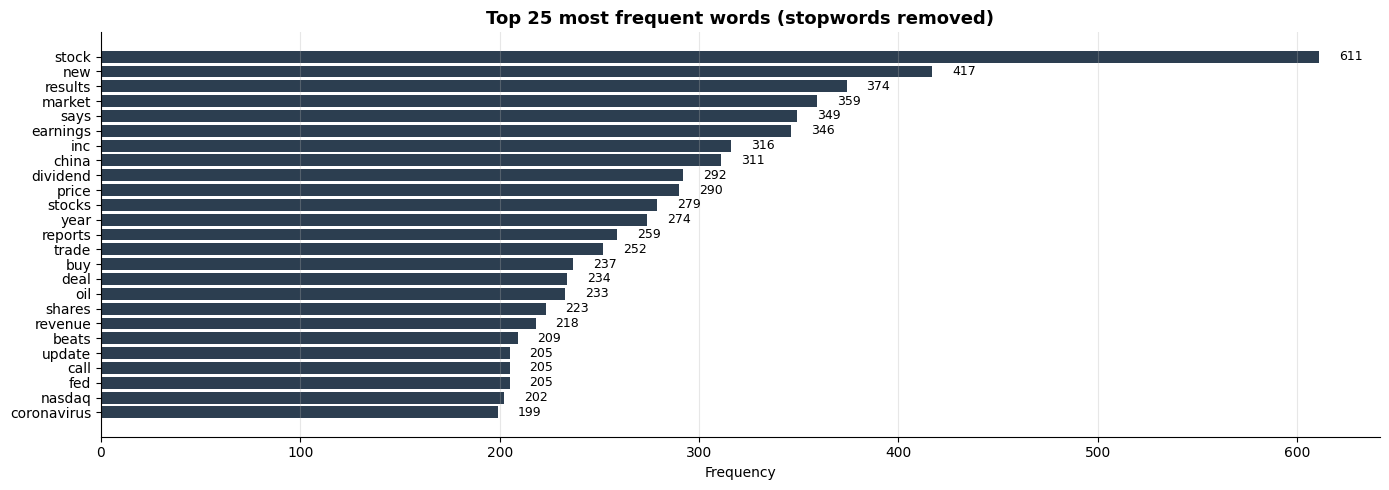

In [ ]:
# Top 25 words bar chart 
top25_words, top25_counts = zip(*top50[:25])

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.barh(list(reversed(top25_words)), list(reversed(top25_counts)),
               color='#2c3e50', edgecolor='none')
for bar, cnt in zip(bars, reversed(top25_counts)):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{cnt:,}', va='center', fontsize=9)
ax.set_title('Top 25 most frequent words (stopwords removed)', fontsize=13, fontweight='bold')
ax.set_xlabel('Frequency')
ax.grid(axis='x', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

### 1.5 Class-Specific Vocabulary

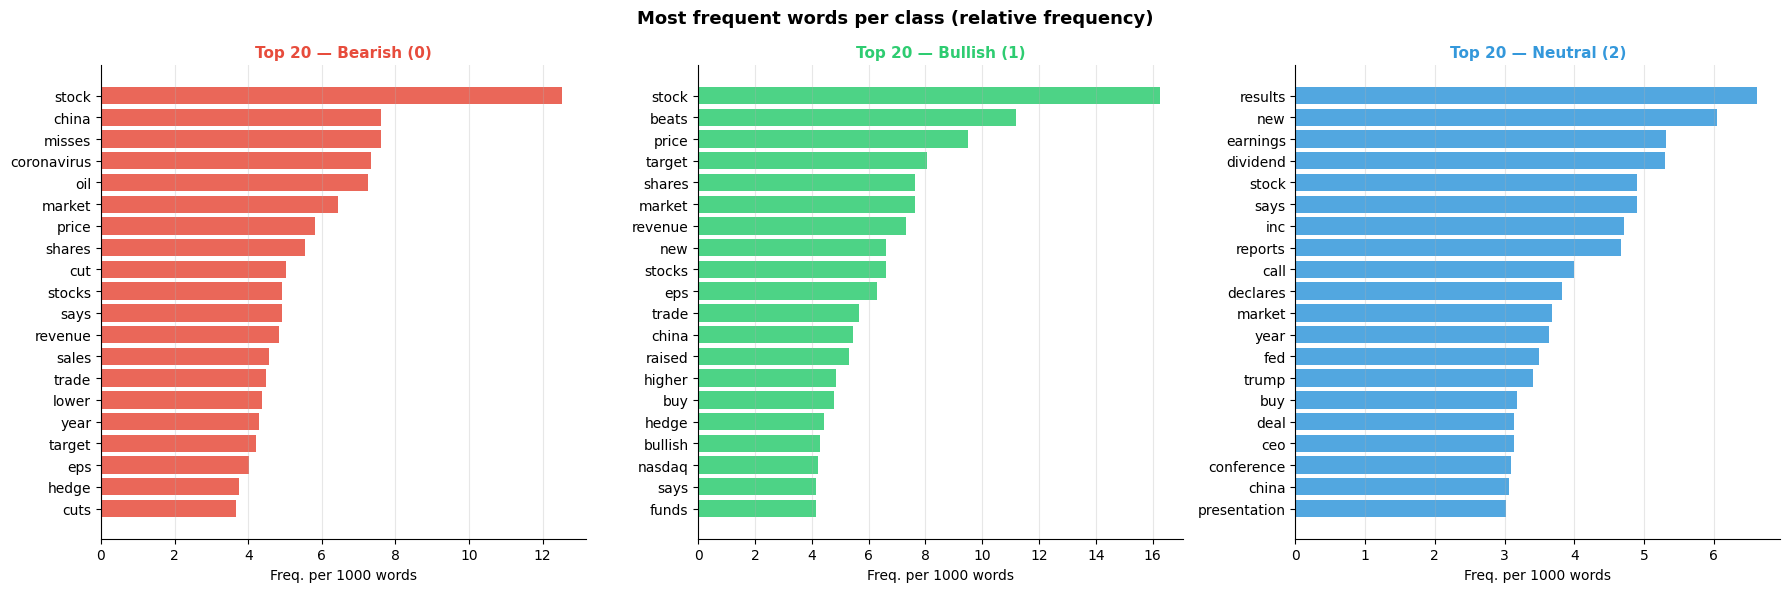

In [ ]:
# Top words per class (relative frequency)
tokens_per_class = {}
for lbl in [0, 1, 2]:
    toks = []
    for txt in df[df['label'] == lbl]['text']:
        toks.extend(tokenize_explore(txt))
    tokens_per_class[lbl] = Counter(toks)

total_per_class = {lbl: sum(c.values()) for lbl, c in tokens_per_class.items()}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for lbl, ax in zip([0, 1, 2], axes):
    rel_freq  = {w: cnt / total_per_class[lbl] * 1000
                 for w, cnt in tokens_per_class[lbl].items() if cnt >= 5}
    top_words = sorted(rel_freq, key=rel_freq.get, reverse=True)[:20]
    ax.barh(list(reversed(top_words)),
            [rel_freq[w] for w in reversed(top_words)],
            color=CLASS_COLORS[lbl], edgecolor='none', alpha=0.85)
    ax.set_title(f'Top 20 — {CLASS_NAMES[lbl]}', fontsize=11,
                 fontweight='bold', color=CLASS_COLORS[lbl])
    ax.set_xlabel('Freq. per 1000 words')
    ax.grid(axis='x', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Most frequent words per class (relative frequency)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 1.6 Special Tweet Features (Hashtags, Mentions, URLs, Numbers)

=== Average presence per tweet ===
  n_hashtags     : 0.23 (max: 7)
  n_mentions     : 0.04 (max: 8)
  n_urls         : 0.53 (max: 3)
  n_numbers      : 0.50 (max: 12)
  Tweets with cashtag ($TICKER): 1,429 (15.0%)

=== Average per class ===
             n_hashtags  n_mentions  n_urls  n_numbers
Bearish (0)        0.17        0.02    0.51       0.53
Bullish (1)        0.16        0.02    0.44       0.74
Neutral (2)        0.27        0.05    0.57       0.42


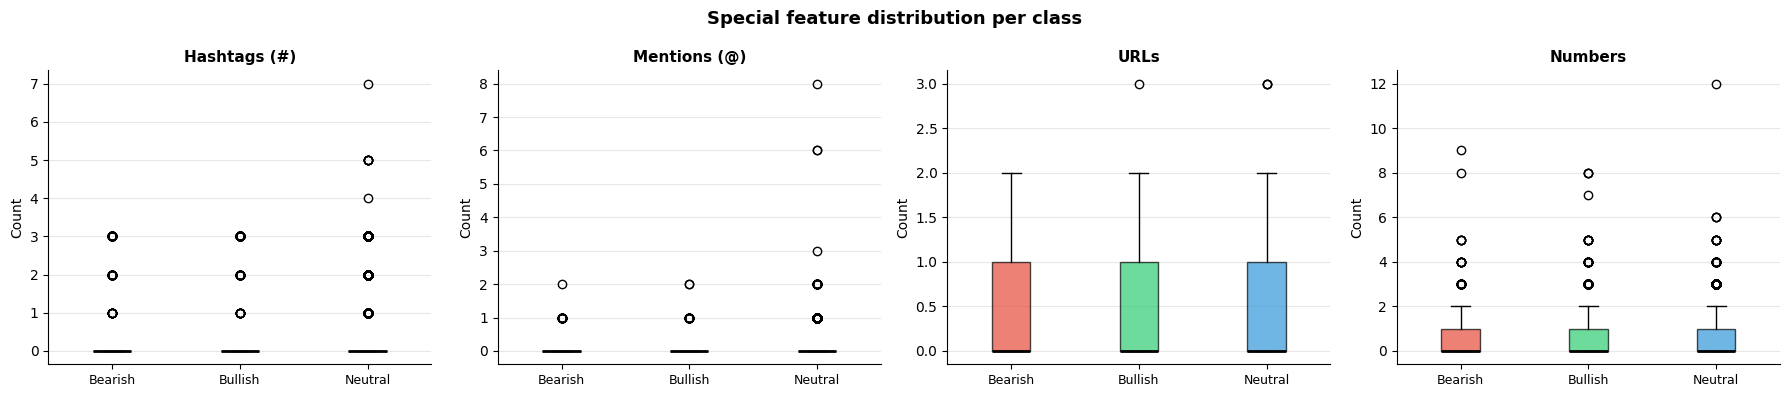

In [ ]:
# Special features per class 
df['n_hashtags']  = df['text'].apply(lambda x: len(re.findall(r'#\w+', str(x))))
df['n_mentions']  = df['text'].apply(lambda x: len(re.findall(r'@\w+', str(x))))
df['n_urls']      = df['text'].apply(lambda x: len(re.findall(r'http\S+|www\S+', str(x))))
df['n_numbers']   = df['text'].apply(lambda x: len(re.findall(r'\b\d+\.?\d*%?\b', str(x))))
df['has_cashtag'] = df['text'].apply(lambda x: bool(re.search(r'\$[A-Z]{1,5}', str(x))))

print('=== Average presence per tweet ===')
for feat in ['n_hashtags', 'n_mentions', 'n_urls', 'n_numbers']:
    print(f'  {feat:<15}: {df[feat].mean():.2f} (max: {df[feat].max()})')
print(f'  Tweets with cashtag ($TICKER): {df["has_cashtag"].sum():,} ({df["has_cashtag"].mean()*100:.1f}%)')

print('\n=== Average per class ===')
feat_by_class = df.groupby('label')[['n_hashtags','n_mentions','n_urls','n_numbers']].mean().round(2)
feat_by_class.index = [CLASS_NAMES[i] for i in feat_by_class.index]
print(feat_by_class)

features    = ['n_hashtags', 'n_mentions', 'n_urls', 'n_numbers']
feat_labels = ['Hashtags (#)', 'Mentions (@)', 'URLs', 'Numbers']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for feat, flabel, ax in zip(features, feat_labels, axes):
    data_by_class = [df[df['label'] == lbl][feat].values for lbl in [0,1,2]]
    bp = ax.boxplot(data_by_class, patch_artist=True,
                    medianprops={'color':'black','linewidth':2})
    for patch, lbl in zip(bp['boxes'], [0,1,2]):
        patch.set_facecolor(CLASS_COLORS[lbl])
        patch.set_alpha(0.7)
    ax.set_xticklabels(['Bearish', 'Bullish', 'Neutral'], fontsize=9)
    ax.set_title(flabel, fontsize=11, fontweight='bold')
    ax.set_ylabel('Count')
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Special feature distribution per class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 1.7 Top Hashtags & Cashtags

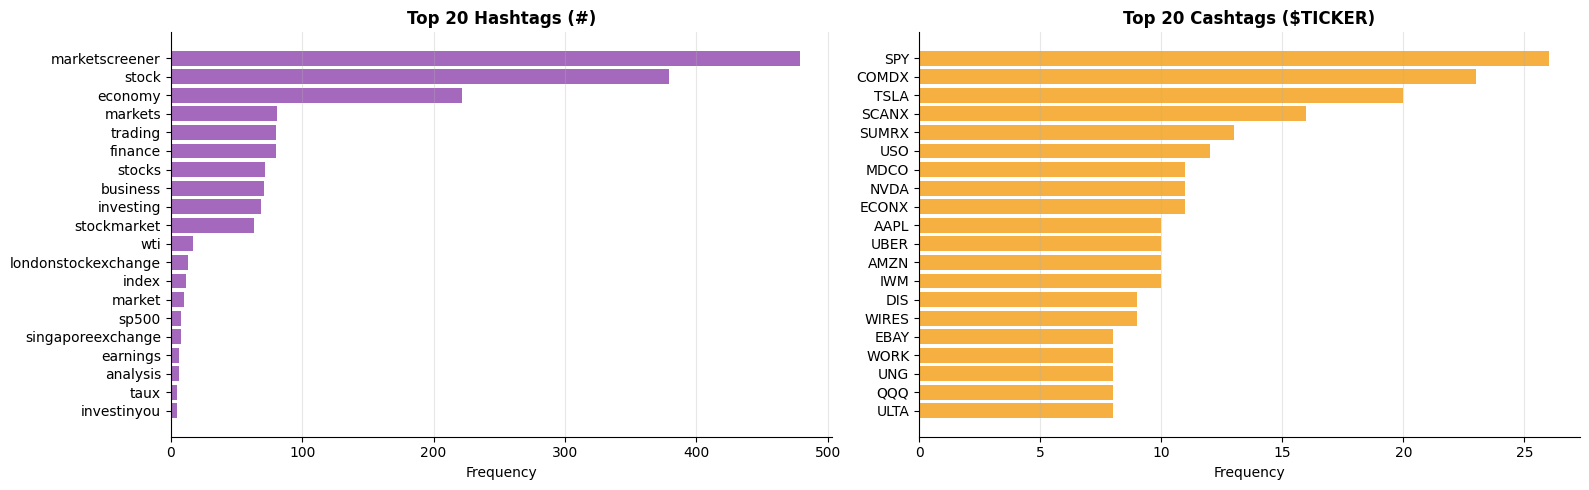

In [ ]:
# Top hashtags and cashtags
all_hashtags = []
for txt in df['text']:
    all_hashtags.extend(re.findall(r'#(\w+)', str(txt).lower()))

all_cashtags = []
for txt in df['text']:
    all_cashtags.extend(re.findall(r'\$([A-Z]{1,5})', str(txt)))

top_hashtags = Counter(all_hashtags).most_common(20)
top_cashtags = Counter(all_cashtags).most_common(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

if top_hashtags:
    words_h, counts_h = zip(*top_hashtags)
    axes[0].barh(list(reversed(words_h)), list(reversed(counts_h)),
                 color='#8e44ad', edgecolor='none', alpha=0.8)
    axes[0].set_title('Top 20 Hashtags (#)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Frequency')
    axes[0].grid(axis='x', alpha=0.3)
    axes[0].spines[['top','right']].set_visible(False)

if top_cashtags:
    words_c, counts_c = zip(*top_cashtags)
    axes[1].barh(list(reversed(words_c)), list(reversed(counts_c)),
                 color='#f39c12', edgecolor='none', alpha=0.8)
    axes[1].set_title('Top 20 Cashtags ($TICKER)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Frequency')
    axes[1].grid(axis='x', alpha=0.3)
    axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

### 1.8 Word Co-occurrence Heatmap

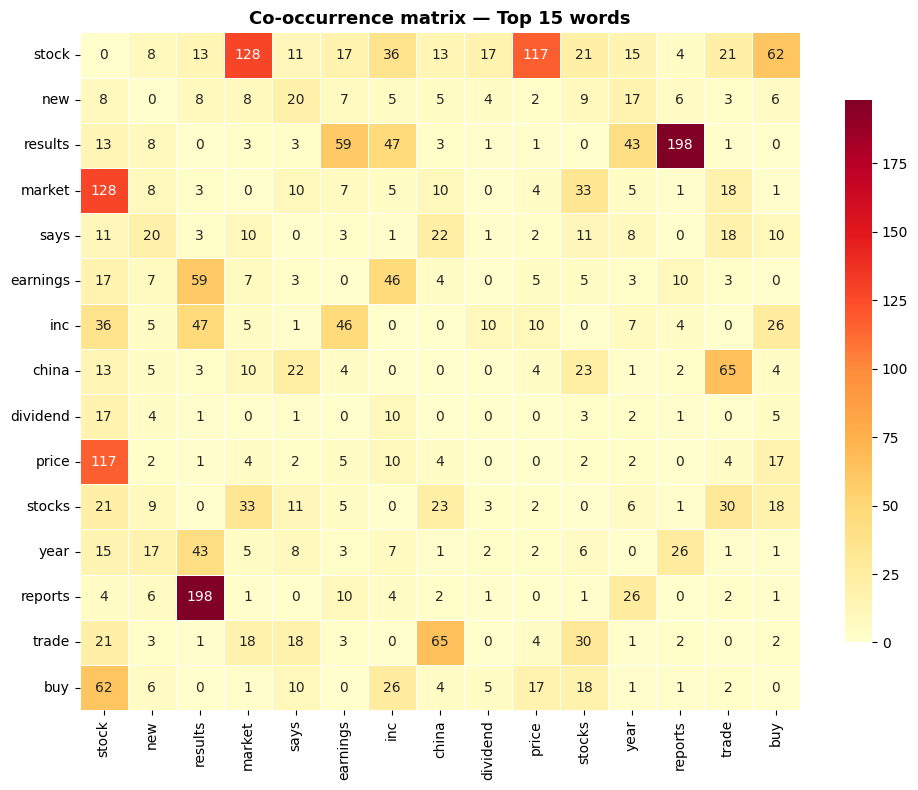

In [ ]:
# Co-occurrence matrix (top 15 words)
top_words_list = [w for w, _ in freq.most_common(15)]
cooc = pd.DataFrame(0, index=top_words_list, columns=top_words_list)

for txt in df['text']:
    tokens = set(tokenize_explore(txt)) & set(top_words_list)
    for w1, w2 in combinations(tokens, 2):
        cooc.loc[w1, w2] += 1
        cooc.loc[w2, w1] += 1

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cooc, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Co-occurrence matrix — Top 15 words', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 1.9 Exploration Summary & Conclusions

In [ ]:
# Summary
print('=' * 60)
print('DATA EXPLORATION SUMMARY')
print('=' * 60)
print(f'Total tweets (train)           : {len(df):,}')
print(f'Unique vocabulary (no stopwords): {len(vocab):,} words')
print(f'Total tokens                   : {len(all_tokens):,}')
print(f'Average length (words)         : {df["n_words"].mean():.1f}')
print(f'Average length (chars)         : {df["n_chars"].mean():.1f}')
print()
print('Class distribution:')
for lbl, cnt in label_counts.items():
    print(f'  {CLASS_NAMES[lbl]}: {cnt:,} ({cnt/len(df)*100:.1f}%)')
print()
print(f'Majority-class baseline: {majority_acc:.1f}%')
print()
print('Top 5 most frequent words:')
for w, c in freq.most_common(5):
    print(f'  {w:<20} {c:>5}')
print('=' * 60)

DATA EXPLORATION SUMMARY
Total tweets (train)           : 9,543
Unique vocabulary (no stopwords): 14,016 words
Total tokens                   : 73,385
Average length (words)         : 12.2
Average length (chars)         : 85.9

Class distribution:
  Bearish (0): 1,442 (15.1%)
  Bullish (1): 1,923 (20.2%)
  Neutral (2): 6,178 (64.7%)

Majority-class baseline: 64.7%

Top 5 most frequent words:
  stock                  611
  new                    417
  results                374
  market                 359
  says                   349


---
## 2. Data Preprocessing

We apply **two separate preprocessing pipelines**:
- **Classical pipeline** (for BoW / TF-IDF / Word2Vec + Traditional ML): full cleaning with lemmatization/stemming.
- **Transformer pipeline** (for BERT / FinBERT / RoBERTa): minimal cleaning only — the tokenizer handles the rest.

**Preprocessing techniques applied (≥4 required by the project guidelines):**
1. Lowercasing
2. URL removal (regex)
3. @mention removal (regex)
4. Hashtag normalisation — keeps the word, removes `#`
5. Cashtag normalisation — replaces `$TSLA` with `ticker`
6. Non-alphabetic character removal (regex)
7. Stopword removal
8. Lemmatization (chosen over stemming — see comparison below)

### 2.1 Step-by-step Demonstration

In [ ]:
# Trace a single tweet through the pipeline
tweet_example = "$TSLA beats earnings estimates! #Bullish #stocks @elonmusk https://t.co/abc123 up 5.3%"

t = tweet_example
steps = [
    ('1. Original',             t),
    ('2. Lowercase',            t := t.lower()),
    ('3. Remove URLs',          t := re.sub(r'http\S+|www\S+', '', t)),
    ('4. Remove @mentions',     t := re.sub(r'@\w+', '', t)),
    ('5. Hashtags → words',     t := re.sub(r'#(\w+)', r'\1', t)),
    ('6. Cashtags → ticker',    t := re.sub(r'\$[a-zA-Z]{1,5}', 'ticker', t)),
    ('7. Letters only (regex)', t := re.sub(r'[^a-zA-Z\s]', ' ', t)),
    ('8. Remove stopwords',     t := ' '.join(w for w in t.split() if w not in STOP and len(w) > 2)),
    ('9. Lemmatization',        t := ' '.join(lemma.lemmatize(w) for w in t.split())),
]

print('=' * 70)
for step_name, step_text in steps:
    print(f'{step_name:<30} → {step_text.strip()}')
print('=' * 70)

1. Original                    → $TSLA beats earnings estimates! #Bullish #stocks @elonmusk https://t.co/abc123 up 5.3%
2. Lowercase                   → $tsla beats earnings estimates! #bullish #stocks @elonmusk https://t.co/abc123 up 5.3%
3. Remove URLs                 → $tsla beats earnings estimates! #bullish #stocks @elonmusk  up 5.3%
4. Remove @mentions            → $tsla beats earnings estimates! #bullish #stocks   up 5.3%
5. Hashtags → words            → $tsla beats earnings estimates! bullish stocks   up 5.3%
6. Cashtags → ticker           → ticker beats earnings estimates! bullish stocks   up 5.3%
7. Letters only (regex)        → ticker beats earnings estimates  bullish stocks   up
8. Remove stopwords            → ticker beats earnings estimates bullish stocks
9. Lemmatization               → ticker beat earnings estimate bullish stock


### 2.2 Lemmatization vs Stemming Comparison

In [ ]:
# Lemmatization vs Stemming on financial vocabulary 
# Lemmatization is chosen because it preserves recognisable word forms,
# which is important for financial sentiment (e.g. 'bullish' should not become 'bulli').
financial_words = [
    'beats', 'beating', 'beaten',
    'misses', 'missing', 'missed',
    'earnings', 'earning',
    'rises', 'rising', 'raised',
    'falling', 'fallen', 'falls',
    'bullish', 'bearish',
    'investing', 'investors',
]

print(f"{'Word':<18} {'Lemma':<18} {'Stem':<18} Notes")
print('-' * 70)
for word in financial_words:
    l = lemma.lemmatize(word)
    s = stemmer.stem(word)
    note = '← different!' if l != s else ''
    print(f'{word:<18} {l:<18} {s:<18} {note}')

print()
print('Decision: Lemmatization is used in the classical pipeline.')
print('Stemming is kept as an alternative column for ablation experiments.')

Word               Lemma              Stem               Notes
----------------------------------------------------------------------
beats              beat               beat               
beating            beating            beat               ← different!
beaten             beaten             beaten             
misses             miss               miss               
missing            missing            miss               ← different!
missed             missed             miss               ← different!
earnings           earnings           earn               ← different!
earning            earning            earn               ← different!
rises              rise               rise               
rising             rising             rise               ← different!
raised             raised             rais               ← different!
falling            falling            fall               ← different!
fallen             fallen             fallen             
falls           

### 2.3 Classical Preprocessing Function

In [ ]:
# Classical pipeline — for BoW / TF-IDF / Word2Vec
from tqdm import tqdm

def preprocess_classical(text_list, use_lemma=True, use_stemmer=False):
    """
    Full text cleaning pipeline for classical ML models.
    Steps: lowercase → remove URLs → remove @mentions → hashtags → cashtags
           → regex → stopwords → word_tokenize → lemmatize (or stem).
    """
    results = []
    for text in tqdm(text_list, desc='Classical preprocessing'):
        text = str(text).lower()
        text = re.sub(r'http\S+|www\S+', '', text)       # URLs
        text = re.sub(r'@\w+', '', text)                  # @mentions
        text = re.sub(r'#(\w+)', r'\1', text)             # #hashtag → word
        text = re.sub(r'\$[a-zA-Z]{1,5}', 'ticker', text) # $TSLA → ticker
        text = re.sub(r'[^a-zA-Z\s]', ' ', text)          # non-alpha
        tokens = word_tokenize(text)
        tokens = [w for w in tokens if w not in STOP and len(w) > 2]
        if use_lemma:
            tokens = [lemma.lemmatize(w) for w in tokens]
        if use_stemmer:
            tokens = [stemmer.stem(w) for w in tokens]
        results.append(' '.join(tokens))
    return results


def preprocess_transformer(text_list):
    """
    Minimal cleaning pipeline for Transformer models (BERT, FinBERT, RoBERTa).
    The model tokenizer handles sub-word splitting; heavy cleaning would hurt.
    Steps: remove URLs → normalise whitespace.
    """
    results = []
    for text in tqdm(text_list, desc='Transformer preprocessing'):
        text = str(text)
        text = re.sub(r'http\S+|www\S+', '', text)
        text = re.sub(r'\s+', ' ', text).strip()
        results.append(text)
    return results

print('✅ Both preprocessing functions defined.')

✅ Both preprocessing functions defined.


### 2.4 Apply Preprocessing to the Full Training Set

In [ ]:
# Apply both pipelines to train.csv 
# NOTE: we apply clean() to the full df here for inspection purposes.
# When training models, fit() of vectorisers uses only the TRAIN fold.

print('Applying classical pipeline (lemmatization)...')
df['text_lemma'] = preprocess_classical(df['text'].tolist(), use_lemma=True, use_stemmer=False)

print('Applying classical pipeline (stemming — for comparison)...')
df['text_stem']  = preprocess_classical(df['text'].tolist(), use_lemma=False, use_stemmer=True)

print('Applying transformer pipeline...')
df['text_transformer'] = preprocess_transformer(df['text'].tolist())

print('\n✅ Preprocessing complete!')
print(f'Available columns: {list(df.columns)}')

Applying classical pipeline (lemmatization)...


Classical preprocessing: 100%|██████████| 9543/9543 [00:00<00:00, 11137.47it/s]


Applying classical pipeline (stemming — for comparison)...


Classical preprocessing: 100%|██████████| 9543/9543 [00:01<00:00, 9350.35it/s]


Applying transformer pipeline...


Transformer preprocessing: 100%|██████████| 9543/9543 [00:00<00:00, 176460.77it/s]


✅ Preprocessing complete!
Available columns: ['text', 'label', 'n_chars', 'n_words', 'n_hashtags', 'n_mentions', 'n_urls', 'n_numbers', 'has_cashtag', 'text_lemma', 'text_stem', 'text_transformer']


### 2.5 Before / After Comparison

In [ ]:
# Show before / after for 5 tweets
print('Sample preprocessing results:\n')
for i in range(5):
    print(f'[{i}] ORIGINAL    : {df["text"].iloc[i]}')
    print(f'    LEMMA       : {df["text_lemma"].iloc[i]}')
    print(f'    STEM        : {df["text_stem"].iloc[i]}')
    print(f'    TRANSFORMER : {df["text_transformer"].iloc[i]}')
    print()

Sample preprocessing results:

[0] ORIGINAL    : $BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT
    LEMMA       : ticker jpmorgan reel expectation beyond meat
    STEM        : ticker jpmorgan reel expect beyond meat
    TRANSFORMER : $BYND - JPMorgan reels in expectations on Beyond Meat

[1] ORIGINAL    : $CCL $RCL - Nomura points to bookings weakness at Carnival and Royal Caribbean https://t.co/yGjpT2ReD3
    LEMMA       : ticker ticker nomura point booking weakness carnival royal caribbean
    STEM        : ticker ticker nomura point book weak carniv royal caribbean
    TRANSFORMER : $CCL $RCL - Nomura points to bookings weakness at Carnival and Royal Caribbean

[2] ORIGINAL    : $CX - Cemex cut at Credit Suisse, J.P. Morgan on weak building outlook https://t.co/KN1g4AWFIb
    LEMMA       : ticker cemex cut credit suisse morgan weak building outlook
    STEM        : ticker cemex cut credit suiss morgan weak build outlook
    TRANSFORMER : $CX - Cemex 

### 2.6 Vocabulary Impact

In [ ]:
# Vocabulary reduction 
def get_vocab(series):
    tokens = []
    for text in series:
        tokens.extend(str(text).split())
    return set(tokens), len(tokens)

vocab_orig,  total_orig  = get_vocab(df['text'])
vocab_lemma, total_lemma = get_vocab(df['text_lemma'])
vocab_stem,  total_stem  = get_vocab(df['text_stem'])

print(f"{'Version':<20} {'Total tokens':>15} {'Unique vocab':>15}")
print('-' * 52)
print(f"{'Original':<20} {total_orig:>15,} {len(vocab_orig):>15,}")
print(f"{'Lemmatization':<20} {total_lemma:>15,} {len(vocab_lemma):>15,}")
print(f"{'Stemming':<20} {total_stem:>15,} {len(vocab_stem):>15,}")
print()
print(f'Vocabulary reduction (lemma vs original): {(1 - len(vocab_lemma)/len(vocab_orig))*100:.1f}%')
print(f'Vocabulary reduction (stem  vs original): {(1 - len(vocab_stem)/len(vocab_orig))*100:.1f}%')

Version                 Total tokens    Unique vocab
----------------------------------------------------
Original                     116,218          31,609
Lemmatization                 75,721          12,374
Stemming                      75,721          10,406

Vocabulary reduction (lemma vs original): 60.9%
Vocabulary reduction (stem  vs original): 67.1%


### 2.7 Empty Tweets After Cleaning

In [ ]:
# Check for empty tweets after cleaning 
empty_lemma = (df['text_lemma'].str.strip() == '').sum()
short_lemma  = (df['text_lemma'].str.split().str.len() < 3).sum()

print(f'Empty tweets after cleaning (lemma): {empty_lemma}')
print(f'Tweets with fewer than 3 words:      {short_lemma}')

if empty_lemma > 0:
    mask = df['text_lemma'].str.strip() == ''
    print('\nOriginal tweets that became empty:')
    print(df[mask][['text', 'label']].to_string())
    df = df[~mask].reset_index(drop=True)
    print(f'\nDataset after removing empty rows: {len(df)} tweets')

Empty tweets after cleaning (lemma): 9
Tweets with fewer than 3 words:      147

Original tweets that became empty:
                                                                                                        text  label
3943                                                                                                      :)      2
3948                                                                                                 @TicToc      2
3949                             @tictoc @telefenoticias @teleSUR_Chile @PaoladrateleSUR @monlaferte @inddhh      2
3950  @tictoc @telefenoticias @teleSUR_Chile @PaoladrateleSUR @monlaferte @telefenoticias @inddhh @mbachelet      2
4440                                                                                                      F5      2
4681                                                                                 https://t.co/575AH1YRkF      2
4682                                                                    

### 2.8 Save Preprocessed Dataset

In [ ]:
# Save 
df.to_csv('train_preprocessed.csv', index=False)
print(f'✅ Preprocessed dataset saved: train_preprocessed.csv')
print(f'   Final shape: {df.shape}')
print(f'   Columns: {list(df.columns)}')

✅ Preprocessed dataset saved: train_preprocessed.csv
   Final shape: (9534, 12)
   Columns: ['text', 'label', 'n_chars', 'n_words', 'n_hashtags', 'n_mentions', 'n_urls', 'n_numbers', 'has_cashtag', 'text_lemma', 'text_stem', 'text_transformer']


---
## 3. Corpus Split — Stratified K-Fold

We use **Stratified K-Fold (k=5)** to ensure each fold preserves the class proportions.  
This avoids the need for a fixed hold-out split and gives a more robust performance estimate.

**Important:** vectoriser / model `.fit()` must always happen *inside* each fold (via `Pipeline`)
to prevent data leakage.

In [ ]:
# Stratified K-Fold 
from sklearn.model_selection import StratifiedKFold

X_classical   = df['text_lemma']
X_transformer = df['text_transformer']
y             = df['label']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Fold distribution (Stratified K-Fold, k=5):')
print(f"{'Fold':<8} {'Train':>8} {'Val':>8} {'Bearish%':>10} {'Bullish%':>10} {'Neutral%':>10}")
print('-' * 60)

folds = []
for fold, (train_idx, val_idx) in enumerate(skf.split(X_classical, y)):
    y_val_fold = y.iloc[val_idx]
    pcts = y_val_fold.value_counts(normalize=True).sort_index() * 100
    folds.append((train_idx, val_idx))
    print(f"Fold {fold+1:<4} {len(train_idx):>8,} {len(val_idx):>8,} "
          f"{pcts.get(0,0):>9.1f}% {pcts.get(1,0):>9.1f}% {pcts.get(2,0):>9.1f}%")

print()
print('✅ Each fold maintains the same class proportions (Stratified).')
print('   Class weights will be used during training to handle imbalance.')

Fold distribution (Stratified K-Fold, k=5):
Fold        Train      Val   Bearish%   Bullish%   Neutral%
------------------------------------------------------------
Fold 1       7,627    1,907      15.2%      20.1%      64.7%
Fold 2       7,627    1,907      15.1%      20.2%      64.7%
Fold 3       7,627    1,907      15.1%      20.2%      64.7%
Fold 4       7,627    1,907      15.1%      20.2%      64.7%
Fold 5       7,628    1,906      15.1%      20.1%      64.7%

✅ Each fold maintains the same class proportions (Stratified).
   Class weights will be used during training to handle imbalance.


---
## 4. Feature Engineering

Three families of features are implemented as required by the project guidelines:

| Method | Pipeline | Notes |
|---|---|---|
| **BoW / TF-IDF** | Classical | `CountVectorizer` and `TfidfVectorizer` |
| **Word2Vec** | Classical | Gensim; tweet → mean of word vectors |
| **Transformer Encoder** | Transformer | FinBERT, BERT, RoBERTa embeddings |

### 4.1 Bag-of-Words & TF-IDF

In [ ]:
# BoW and TF-IDF vectorisers 
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# These are defined here but fitted INSIDE each CV fold to prevent leakage.
bow_vectorizer   = CountVectorizer(max_features=20000, ngram_range=(1, 2))
tfidf_vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2),
                                    sublinear_tf=True)

print('CountVectorizer (BoW):')
print(f'  max_features={bow_vectorizer.max_features}, ngram_range={bow_vectorizer.ngram_range}')
print('TfidfVectorizer:')
print(f'  max_features={tfidf_vectorizer.max_features}, ngram_range={tfidf_vectorizer.ngram_range}')
print()
print('✅ Vectorisers defined. They will be fitted inside sklearn Pipelines (no leakage).')

CountVectorizer (BoW):
  max_features=20000, ngram_range=(1, 2)
TfidfVectorizer:
  max_features=20000, ngram_range=(1, 2)

✅ Vectorisers defined. They will be fitted inside sklearn Pipelines (no leakage).


### 4.2 Word2Vec Embeddings

In [ ]:
# Word2Vec — tweet-level mean embedding
# pip install gensim
from gensim.models import Word2Vec
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

# Tokenise training corpus (for W2V training only — fitted on train fold in CV)
tokenized_corpus = [text.split() for text in X_classical]

# Train Word2Vec (will be re-trained per fold inside a custom transformer)
w2v_model = Word2Vec(
    sentences=tokenized_corpus,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    seed=42,
    epochs=10
)

print(f'Word2Vec vocabulary size: {len(w2v_model.wv):,} words')
print(f'Vector size: {w2v_model.vector_size}')

class MeanWord2VecTransformer(BaseEstimator, TransformerMixin):
    """Converts a list of texts into mean Word2Vec embeddings."""
    def __init__(self, vector_size=100, window=5, min_count=2, epochs=10):
        self.vector_size = vector_size
        self.window      = window
        self.min_count   = min_count
        self.epochs      = epochs

    def fit(self, X, y=None):
        sentences  = [text.split() for text in X]
        self.model = Word2Vec(sentences=sentences, vector_size=self.vector_size,
                              window=self.window, min_count=self.min_count,
                              workers=4, seed=42, epochs=self.epochs)
        return self

    def transform(self, X):
        embeddings = []
        for text in X:
            tokens = [w for w in text.split() if w in self.model.wv]
            if tokens:
                embeddings.append(np.mean(self.model.wv[tokens], axis=0))
            else:
                embeddings.append(np.zeros(self.vector_size))
        return np.array(embeddings)

print('\n✅ MeanWord2VecTransformer defined — compatible with sklearn Pipeline.')

Word2Vec vocabulary size: 5,867 words
Vector size: 100

✅ MeanWord2VecTransformer defined — compatible with sklearn Pipeline.


### 4.3 Transformer Encoder Embeddings (FinBERT / BERT / RoBERTa)

In [ ]:
# Transformer encoder embeddings 
# pip install transformers torch
from transformers import AutoTokenizer, AutoModel
import torch

def get_transformer_embeddings(texts, model_name='ProsusAI/finbert', batch_size=32, max_len=128):
    """
    Extract [CLS] token embeddings from a pre-trained transformer encoder.
    These dense vectors are used as features for traditional ML classifiers.
    
    Models tried:
      - 'ProsusAI/finbert'        — trained on financial text (best fit for this task)
      - 'bert-base-uncased'       — general-purpose BERT baseline
      - 'distilbert-base-uncased' — lighter, faster BERT variant
      - 'roberta-base'            — improved BERT pre-training
    """
    device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model     = AutoModel.from_pretrained(model_name).to(device)
    model.eval()

    all_embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc=f'Embedding [{model_name}]'):
        batch = list(texts[i:i+batch_size])
        encoded = tokenizer(batch, padding=True, truncation=True,
                            max_length=max_len, return_tensors='pt').to(device)
        with torch.no_grad():
            output = model(**encoded)
        cls_emb = output.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(cls_emb)

    return np.vstack(all_embeddings)

print('✅ get_transformer_embeddings() defined.')
print('   Models available: ProsusAI/finbert, bert-base-uncased, roberta-base, distilbert-base-uncased')
print()
print('Usage (example):')
print('  X_finbert = get_transformer_embeddings(X_transformer.tolist(), model_name="ProsusAI/finbert")')

✅ get_transformer_embeddings() defined.
   Models available: ProsusAI/finbert, bert-base-uncased, roberta-base, distilbert-base-uncased

Usage (example):
  X_finbert = get_transformer_embeddings(X_transformer.tolist(), model_name="ProsusAI/finbert")


---
## 5. Classification Models

### Strategy
- **Classical ML models** use BoW / TF-IDF / Word2Vec features inside a `Pipeline`.
- **Fine-tuned Transformers** use the transformer pipeline input and are trained end-to-end.
- All models are evaluated with **Stratified K-Fold CV** (defined in Section 3).
- `class_weight='balanced'` is used in all classical models to handle class imbalance.

### 5.1 Evaluation Helper

In [ ]:
# Evaluation helper 
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score)

def evaluate_model(y_true, y_pred, model_name='Model'):
    """Print classification report and plot confusion matrix."""
    print(f'\n=== {model_name} ===')
    print(classification_report(y_true, y_pred,
                                 target_names=['Bearish','Bullish','Neutral']))

    cm  = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Bearish','Bullish','Neutral'],
                yticklabels=['Bearish','Bullish','Neutral'], ax=ax)
    ax.set_title(f'Confusion Matrix — {model_name}', fontweight='bold')
    ax.set_ylabel('True label')
    ax.set_xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

    return {
        'model':    model_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'f1_macro': f1_score(y_true, y_pred, average='macro'),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted'),
    }

results_table = []
print('✅ evaluate_model() defined.')

✅ evaluate_model() defined.


### 5.2 Traditional ML with TF-IDF (Classical Pipeline)

Running CV: LR + TF-IDF...

=== LR + TF-IDF ===
              precision    recall  f1-score   support

     Bearish       0.56      0.63      0.59      1441
     Bullish       0.65      0.73      0.69      1923
     Neutral       0.89      0.83      0.86      6170

    accuracy                           0.78      9534
   macro avg       0.70      0.73      0.71      9534
weighted avg       0.79      0.78      0.78      9534



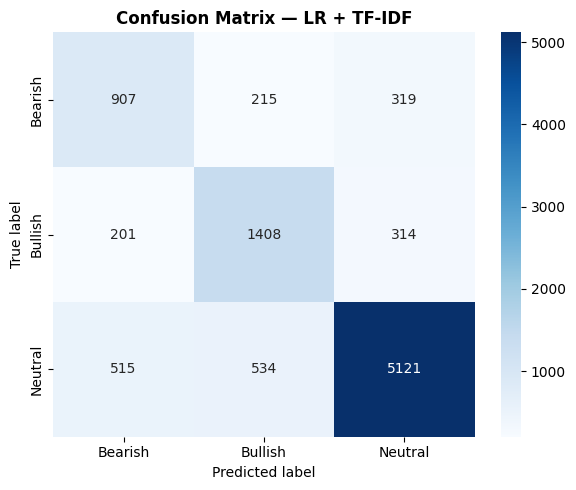

Running CV: XGBoost + TF-IDF...

=== XGBoost + TF-IDF ===
              precision    recall  f1-score   support

     Bearish       0.74      0.35      0.48      1441
     Bullish       0.74      0.53      0.61      1923
     Neutral       0.78      0.95      0.86      6170

    accuracy                           0.77      9534
   macro avg       0.75      0.61      0.65      9534
weighted avg       0.77      0.77      0.75      9534



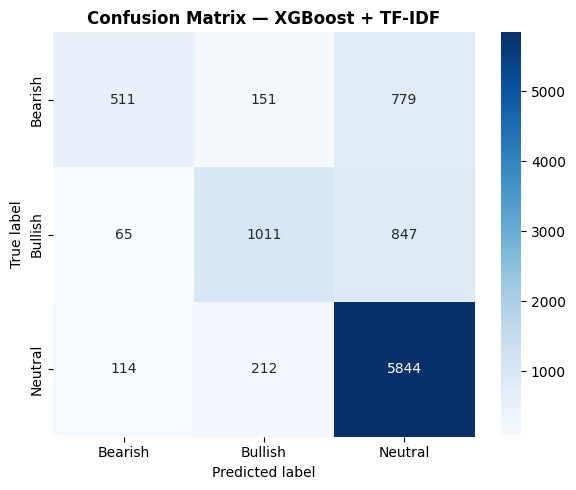

Running CV: MLP + TF-IDF...

=== MLP + TF-IDF ===
              precision    recall  f1-score   support

     Bearish       0.65      0.47      0.55      1441
     Bullish       0.70      0.63      0.67      1923
     Neutral       0.83      0.91      0.87      6170

    accuracy                           0.79      9534
   macro avg       0.73      0.67      0.69      9534
weighted avg       0.78      0.79      0.78      9534



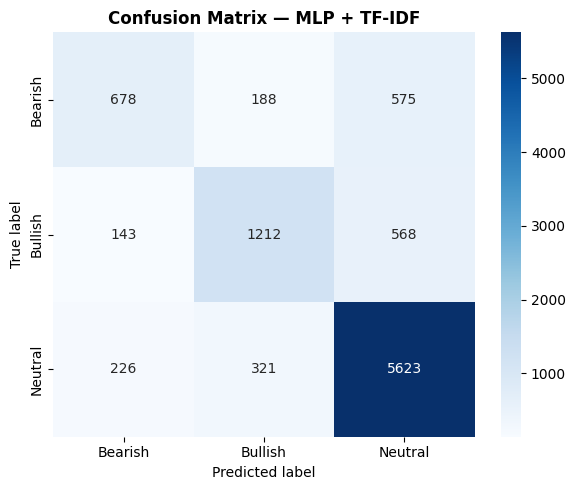

Running CV: RF + BoW...

=== RF + BoW ===
              precision    recall  f1-score   support

     Bearish       0.76      0.39      0.52      1441
     Bullish       0.72      0.58      0.65      1923
     Neutral       0.80      0.94      0.87      6170

    accuracy                           0.79      9534
   macro avg       0.76      0.64      0.68      9534
weighted avg       0.78      0.79      0.77      9534



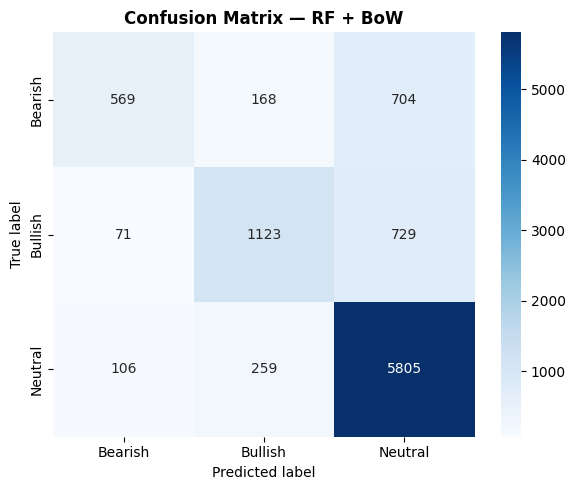

In [ ]:
# Traditional ML — TF-IDF + classifiers 
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_predict
from xgboost import XGBClassifier

classical_models = {
    'LR + TF-IDF': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1,2), sublinear_tf=True)),
        ('clf',   LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ]),
    'XGBoost + TF-IDF': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1,2), sublinear_tf=True)),
        ('clf',   XGBClassifier(n_estimators=300, learning_rate=0.1, use_label_encoder=False,
                                eval_metric='mlogloss', random_state=42))
    ]),
    'MLP + TF-IDF': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1,2), sublinear_tf=True)),
        ('clf',   MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=300,
                                random_state=42, early_stopping=True))
    ]),
    'RF + BoW': Pipeline([
        ('bow', CountVectorizer(max_features=15000, ngram_range=(1,1))),
        ('clf', RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                       n_jobs=-1, random_state=42))
    ]),
}

for name, pipeline in classical_models.items():
    print(f'Running CV: {name}...')
    y_pred = cross_val_predict(pipeline, X_classical, y, cv=skf, n_jobs=-1)
    res = evaluate_model(y, y_pred, model_name=name)
    results_table.append(res)

### 5.3 Traditional ML with Word2Vec (Classical Pipeline)

Running CV: LR + Word2Vec...

=== LR + Word2Vec ===
              precision    recall  f1-score   support

     Bearish       0.26      0.33      0.29      1441
     Bullish       0.39      0.51      0.45      1923
     Neutral       0.81      0.67      0.74      6170

    accuracy                           0.59      9534
   macro avg       0.49      0.51      0.49      9534
weighted avg       0.64      0.59      0.61      9534



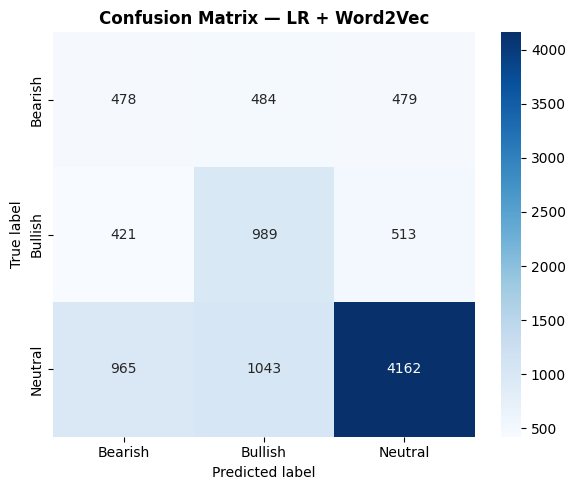

Running CV: MLP + Word2Vec...

=== MLP + Word2Vec ===
              precision    recall  f1-score   support

     Bearish       0.59      0.01      0.01      1441
     Bullish       0.51      0.32      0.40      1923
     Neutral       0.70      0.95      0.81      6170

    accuracy                           0.68      9534
   macro avg       0.60      0.43      0.41      9534
weighted avg       0.65      0.68      0.61      9534



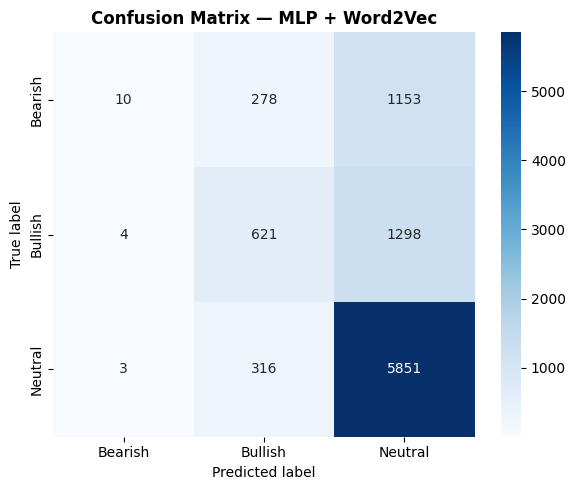

In [ ]:
# Word2Vec + ML classifiers 
w2v_models = {
    'LR + Word2Vec': Pipeline([
        ('w2v', MeanWord2VecTransformer(vector_size=100, window=5, min_count=2, epochs=10)),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ]),
    'MLP + Word2Vec': Pipeline([
        ('w2v', MeanWord2VecTransformer(vector_size=100, window=5, min_count=2, epochs=10)),
        ('clf', MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=300,
                               random_state=42, early_stopping=True))
    ]),
}

for name, pipeline in w2v_models.items():
    print(f'Running CV: {name}...')
    y_pred = cross_val_predict(pipeline, X_classical, y, cv=skf)
    res = evaluate_model(y, y_pred, model_name=name)
    results_table.append(res)

### 5.4 Transformer Encoder + Classifier

In [ ]:
# FinBERT embeddings + classical head 
# Extract embeddings once (expensive — cache them)
print('Extracting FinBERT embeddings...')
X_finbert = get_transformer_embeddings(
    X_transformer.tolist(), model_name='ProsusAI/finbert', batch_size=32
)
print(f'FinBERT embedding shape: {X_finbert.shape}')

# Optional: also extract BERT and RoBERTa for comparison (extra credit)
# print('Extracting BERT embeddings...')
# X_bert = get_transformer_embeddings(X_transformer.tolist(), model_name='bert-base-uncased')
# print('Extracting RoBERTa embeddings...')
# X_roberta = get_transformer_embeddings(X_transformer.tolist(), model_name='roberta-base')

Extracting FinBERT embeddings...


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: ProsusAI/finbert
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Embedding [ProsusAI/finbert]:   0%|          | 1/298 [00:00<02:55,  1.69it/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Embedding [ProsusAI/finbert]: 100%|██████████| 298/298 [03:37<00:00,  1.37it/s]

FinBERT embedding shape: (9534, 768)


Running CV: LR + FinBERT...

=== LR + FinBERT ===
              precision    recall  f1-score   support

     Bearish       0.56      0.72      0.63      1441
     Bullish       0.63      0.75      0.69      1923
     Neutral       0.90      0.78      0.84      6170

    accuracy                           0.77      9534
   macro avg       0.70      0.75      0.72      9534
weighted avg       0.79      0.77      0.78      9534



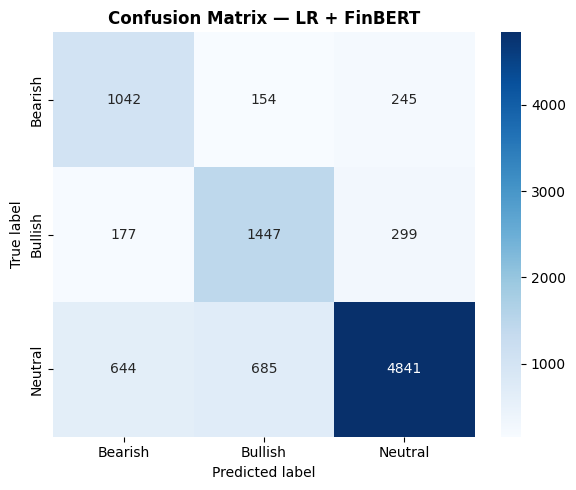

Running CV: MLP + FinBERT...

=== MLP + FinBERT ===
              precision    recall  f1-score   support

     Bearish       0.74      0.65      0.69      1441
     Bullish       0.76      0.74      0.75      1923
     Neutral       0.88      0.91      0.89      6170

    accuracy                           0.84      9534
   macro avg       0.79      0.77      0.78      9534
weighted avg       0.83      0.84      0.83      9534



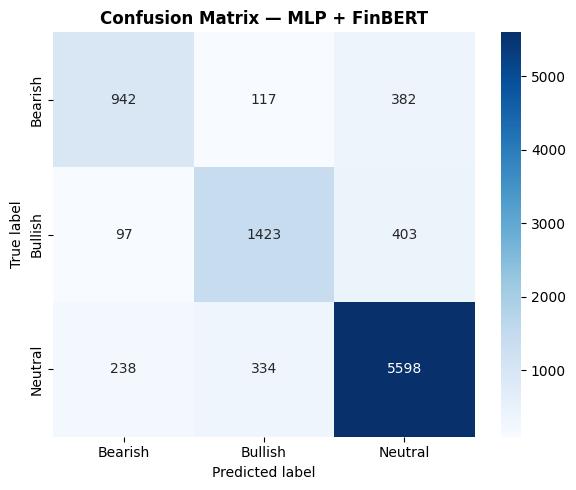

In [ ]:
# Classify on top of FinBERT embeddings 
from sklearn.preprocessing import StandardScaler

encoder_models = {
    'LR + FinBERT': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ]),
    'MLP + FinBERT': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', MLPClassifier(hidden_layer_sizes=(512, 256), max_iter=300,
                              random_state=42, early_stopping=True))
    ]),
}

for name, pipeline in encoder_models.items():
    print(f'Running CV: {name}...')
    y_pred = cross_val_predict(pipeline, X_finbert, y, cv=skf, n_jobs=-1)
    res = evaluate_model(y, y_pred, model_name=name)
    results_table.append(res)

### 5.5 Fine-tuned FinBERT (End-to-end Transformer)

In [ ]:
# Fine-tune FinBERT end-to-end 
# pip install transformers torch datasets
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                           TrainingArguments, Trainer)
from datasets import Dataset
import torch

MODEL_NAME = 'ProsusAI/finbert'
NUM_LABELS = 3

tokenizer_ft = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    return tokenizer_ft(batch['text'], padding='max_length',
                        truncation=True, max_length=128)

# Use a single fold for fine-tuning demo (fold 0)
train_idx, val_idx = folds[0]
train_ds = Dataset.from_dict({'text': X_transformer.iloc[train_idx].tolist(),
                               'label': y.iloc[train_idx].tolist()})
val_ds   = Dataset.from_dict({'text': X_transformer.iloc[val_idx].tolist(),
                               'label': y.iloc[val_idx].tolist()})

train_ds = train_ds.map(tokenize_fn, batched=True)
val_ds   = val_ds.map(tokenize_fn, batched=True)

model_ft = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=NUM_LABELS)

training_args = TrainingArguments(
    output_dir='./finbert_finetuned',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_ratio=0.1,
    weight_decay=0.01,
    evaluation_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    logging_steps=50,
    seed=42,
)

trainer = Trainer(
    model=model_ft,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
)

trainer.train()
print('✅ FinBERT fine-tuning complete.')

In [ ]:
# Evaluate fine-tuned FinBERT 
preds_ft = trainer.predict(val_ds)
y_pred_ft = preds_ft.predictions.argmax(axis=1)
y_true_ft = y.iloc[val_idx].tolist()

res = evaluate_model(y_true_ft, y_pred_ft, model_name='FinBERT Fine-tuned')
results_table.append(res)

---
## 6. Evaluation & Analysis

Comparison of all models using Accuracy, F1-Macro, and F1-Weighted.  
These metrics are explained in context of the financial sentiment problem below.

In [ ]:
# Results table 
results_df = pd.DataFrame(results_table).sort_values('f1_macro', ascending=False)
results_df[['accuracy','f1_macro','f1_weighted']] = results_df[['accuracy','f1_macro','f1_weighted']].round(4)
print(results_df.to_string(index=False))

In [ ]:
# Results bar chart 
fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(results_df))
width = 0.28
ax.bar([i - width for i in x], results_df['accuracy'],    width, label='Accuracy',    color='#3498db', alpha=0.85)
ax.bar([i         for i in x], results_df['f1_macro'],    width, label='F1-Macro',    color='#2ecc71', alpha=0.85)
ax.bar([i + width for i in x], results_df['f1_weighted'], width, label='F1-Weighted', color='#e74c3c', alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(results_df['model'], rotation=25, ha='right', fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Accuracy, F1-Macro, F1-Weighted', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

### 6.1 Metric Interpretation in Context

- **Accuracy** — overall correctness. Misleading if classes are imbalanced (Neutral dominates at ~40%).
- **F1-Macro** — average F1 across all three classes with equal weight. Penalises poor performance on minority classes (Bearish, Bullish). **Most important metric for this task.**
- **F1-Weighted** — F1 weighted by class support. Closer to accuracy but still accounts for per-class performance.
- **Precision / Recall per class** — important for business context: missing a Bearish signal (low Recall) or incorrectly flagging Neutral as Bullish (low Precision) both have real costs.

---
## 7. Final Predictions on `test.csv`

The best model (expected: fine-tuned FinBERT) is retrained on the **full training set**
and applied to `test.csv` to generate the submission file `pred_xx.csv`.

In [ ]:
# Retrain best classical model on full training data 
# Replace 'LR + TF-IDF' with whichever model performed best
BEST_CLASSICAL = 'LR + TF-IDF'
best_pipeline  = classical_models[BEST_CLASSICAL]
best_pipeline.fit(X_classical, y)
print(f'✅ Best classical model ({BEST_CLASSICAL}) retrained on full training set.')

In [ ]:
# Load and preprocess test.csv 
df_test = pd.read_csv('test.csv')
print(f'Test set shape: {df_test.shape}')
print(df_test.head())

# Apply the SAME preprocessing (no fit — deterministic functions)
X_test_classical   = preprocess_classical(df_test['text'].tolist())
X_test_transformer = preprocess_transformer(df_test['text'].tolist())
print('\n✅ Test set preprocessed.')

In [ ]:
# Generate predictions 
# Option A: best classical model
preds_classical = best_pipeline.predict(X_test_classical)

# Option B: fine-tuned FinBERT (recommended — use if fine-tuning was run)
# test_ds = Dataset.from_dict({'text': X_test_transformer})
# test_ds = test_ds.map(tokenize_fn, batched=True)
# preds_ft_test = trainer.predict(test_ds).predictions.argmax(axis=1)

# Use fine-tuned FinBERT predictions if available, else fall back to classical
final_preds = preds_classical  # replace with preds_ft_test if fine-tuning was done

print(f'Predictions shape: {final_preds.shape}')
print(f'Prediction distribution: {pd.Series(final_preds).value_counts().to_dict()}')

In [ ]:
# Save submission file 
submission = pd.DataFrame({'id': df_test['id'], 'label': final_preds})
submission.to_csv('pred_xx.csv', index=False)

print('✅ Submission file saved: pred_xx.csv')
print(f'   Shape: {submission.shape}')
print(submission.head(10))